# Detection Results Comparison : DINO against custom YOLO

# Qualitative Results

In [1]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob
import matplotlib.patches as patches

# --- YOLO Imports ---
from ultralytics import YOLO

# --- Grounding DINO Imports ---
import groundingdino
from groundingdino.util.inference import load_model as load_dino_model, predict
import groundingdino.datasets.transforms as T



In [14]:

# ==========================================
# 1. CONFIGURATION & MODEL LOADING
# ==========================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- YOLO Setup ---
YOLO_WEIGHTS = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\weights\detection\detection_Only_training_run-with-medium_pretrained_weights_without_augmentations\weights\best.pt"
print(f"Loading Custom YOLO on {DEVICE}...")
yolo_model = YOLO(YOLO_WEIGHTS)

# --- Grounding DINO Setup ---
dino_pkg_dir = os.path.dirname(groundingdino.__file__)
DINO_CONFIG = os.path.join(dino_pkg_dir, "config", "GroundingDINO_SwinT_OGC.py")
DINO_WEIGHTS = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\weights\detection\groundingdino_swint_ogc.pth"
print(f"Loading Grounding DINO on {DEVICE}...")
dino_model = load_dino_model(DINO_CONFIG, DINO_WEIGHTS).to(DEVICE)
DINO_PROMPT = "fish"


Loading Custom YOLO on cpu...
Loading Grounding DINO on cpu...
final text_encoder_type: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:

# ==========================================
# 2. INFERENCE HELPERS
# ==========================================
def get_yolo_predictions(image_bgr, conf_thresh=0.25):
    """Runs YOLO and returns a list of [x1, y1, x2, y2, conf, class_name]"""
    results = yolo_model.predict(image_bgr, conf=conf_thresh, verbose=False)[0]

    predictions = []
    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        conf = box.conf[0].cpu().item()
        cls_id = int(box.cls[0].cpu().item())
        cls_name = yolo_model.names[cls_id]
        predictions.append([int(x1), int(y1), int(x2), int(y2), conf, cls_name])

    return predictions

def get_dino_predictions(image_bgr, prompt, box_thresh=0.35, text_thresh=0.25):
    """Runs DINO and returns a list of [x1, y1, x2, y2, conf, phrase]"""
    # Transform for DINO
    transform = T.Compose([
        T.RandomResize([800], max_size=1333),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    image_pil = Image.fromarray(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    image_transformed, _ = transform(image_pil, None)

    # Predict
    boxes, logits, phrases = predict(
        model=dino_model,
        image=image_transformed,
        caption=prompt,
        box_threshold=box_thresh,
        text_threshold=text_thresh,
        device=DEVICE
    )

    if len(boxes) == 0:
        return []

    # Convert normalized [cx, cy, w, h] to absolute [x1, y1, x2, y2]
    h, w, _ = image_bgr.shape
    boxes_xyxy = boxes * torch.Tensor([w, h, w, h])
    boxes_xyxy[:, :2] -= boxes_xyxy[:, 2:] / 2  # top-left
    boxes_xyxy[:, 2:] += boxes_xyxy[:, :2]      # bottom-right

    predictions = []
    for i in range(len(boxes_xyxy)):
        x1, y1, x2, y2 = boxes_xyxy[i].cpu().numpy()
        conf = logits[i].cpu().item()
        phrase = phrases[i]
        predictions.append([int(x1), int(y1), int(x2), int(y2), conf, phrase])

    return predictions


In [16]:
# ==========================================
# 3. VISUALIZATION HELPER
# ==========================================
def draw_boxes(image_bgr, predictions, color=(0, 255, 0), thickness=2):
    """Draws bounding boxes and labels on a copy of the image."""
    img_draw = image_bgr.copy()
    for x1, y1, x2, y2, conf, label in predictions:
        # Draw Box
        cv2.rectangle(img_draw, (x1, y1), (x2, y2), color, thickness)

        # Draw Label Background
        text = f"{label} {conf:.2f}"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.6
        text_size, _ = cv2.getTextSize(text, font, font_scale, 1)
        cv2.rectangle(img_draw, (x1, y1 - text_size[1] - 5), (x1 + text_size[0], y1), color, -1)

        # Draw Text
        cv2.putText(img_draw, text, (x1, y1 - 5), font, font_scale, (0, 0, 0), 2)

    return img_draw


In [17]:

def get_area(box):
    """Calculates the area of a bounding box [x1, y1, x2, y2]."""
    return max(0, box[2] - box[0]) * max(0, box[3] - box[1])

def calculate_overlap_metrics(boxA, boxB):
    """Calculates both Standard IoU and IoMin."""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0, 0.0

    boxAArea = get_area(boxA)
    boxBArea = get_area(boxB)

    iou = interArea / float(boxAArea + boxBArea - interArea)
    io_min = interArea / float(min(boxAArea, boxBArea))

    return iou, io_min

def filter_overlapping_boxes_prefer_small(predictions, iou_threshold=0.45, iomin_threshold=0.80):
    """
    Filters overlapping bounding boxes, heavily favoring smaller, tighter boxes.
    """
    if len(predictions) <= 1:
        return predictions

    # ==========================================
    # PHASE 1: The "Anti-Swallow" Filter
    # If one box is swallowed by another, kill the LARGER box.
    # ==========================================
    skip_indices = set()

    for i in range(len(predictions)):
        if i in skip_indices:
            continue

        boxA = predictions[i][0:4]
        areaA = get_area(boxA)

        for j in range(i + 1, len(predictions)):
            if j in skip_indices:
                continue

            boxB = predictions[j][0:4]
            areaB = get_area(boxB)

            iou, io_min = calculate_overlap_metrics(boxA, boxB)

            # If the smaller box is almost entirely inside the larger box
            if io_min > iomin_threshold:
                # Mark the LARGER box for deletion
                if areaA > areaB:
                    skip_indices.add(i)
                    break # Box A is dead, stop comparing it and move to next i
                else:
                    skip_indices.add(j) # Box B is dead

    # Keep only the boxes that survived Phase 1
    phase_1_survivors = [predictions[i] for i in range(len(predictions)) if i not in skip_indices]

    # ==========================================
    # PHASE 2: Standard Confidence-Based NMS
    # Clean up any remaining standard overlaps by favoring higher confidence.
    # ==========================================
    # Sort survivors by confidence (index 4) descending
    sorted_preds = sorted(phase_1_survivors, key=lambda x: x[4], reverse=True)
    final_predictions = []

    for current_pred in sorted_preds:
        current_box = current_pred[0:4]
        keep = True

        for kept_pred in final_predictions:
            kept_box = kept_pred[0:4]
            iou, _ = calculate_overlap_metrics(current_box, kept_box)

            if iou > iou_threshold:
                keep = False
                break

        if keep:
            final_predictions.append(current_pred)

    return final_predictions


In [18]:
# ==========================================
# 4. MANUAL STATIC COMPARISON
# ==========================================

def display_inline_comparison(image_path, yolo_conf=0.25, dino_box_thresh=0.30):
    """Processes a single image and prints a side-by-side Matplotlib visualization."""
    filename = os.path.basename(image_path)
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Error: Could not read image {filename}")
        return

    # Convert BGR to RGB for matplotlib presentation
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Inference & Filtering
    raw_dino_preds = get_dino_predictions(img_bgr, prompt=DINO_PROMPT, box_thresh=dino_box_thresh)
    raw_yolo_preds = get_yolo_predictions(img_bgr, conf_thresh=yolo_conf)
    dino_preds = filter_overlapping_boxes_prefer_small(raw_dino_preds)
    yolo_preds = filter_overlapping_boxes_prefer_small(raw_yolo_preds)

    # Setup Side-by-Side Plotting Configuration
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    fig.suptitle(f"Comparison: {filename}", fontsize=18, fontweight='bold', y=0.95)

    # --- Panel 1: Grounding DINO ---
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Grounding DINO (Found: {len(dino_preds)})", fontsize=14, color='darkorange')
    axes[0].axis('off')
    for x1, y1, x2, y2, conf, label in dino_preds:
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='darkorange', facecolor='none')
        axes[0].add_patch(rect)
        axes[0].text(x1, y1 - 8, f"{label} {conf:.2f}", color='white', fontsize=10,
                     weight='bold', bbox=dict(facecolor='darkorange', alpha=0.8, edgecolor='none', pad=2))

    # --- Panel 2: Custom YOLOv8 ---
    axes[1].imshow(img_rgb)
    axes[1].set_title(f"Custom YOLO (Found: {len(yolo_preds)})", fontsize=14, color='limegreen')
    axes[1].axis('off')
    for x1, y1, x2, y2, conf, label in yolo_preds:
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='limegreen', facecolor='none')
        axes[1].add_patch(rect)
        axes[1].text(x1, y1 - 8, f"{label} {conf:.2f}", color='black', fontsize=10,
                     weight='bold', bbox=dict(facecolor='limegreen', alpha=0.8, edgecolor='none', pad=2))

    plt.tight_layout()
    plt.show()

In [19]:
# 1. Collect and parse the targeted files
TEST_FOLDER = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\CLEAN_CODE\data\processed\UMT\untouched_images_for_assessment\selected_untouched_images"
valid_extensions = ('*.jpg', '*.jpeg', '*.png')
image_paths = []
for ext in valid_extensions:
    image_paths.extend(glob.glob(os.path.join(TEST_FOLDER, ext)))
image_paths.sort()

if not image_paths:
    print(f"No valid images found in: {TEST_FOLDER}")
else:
    print(f"Successfully tracked {len(image_paths)} images.")
    
    # --- INTERACTIVE CONTROL CELL ---
    # Adjust this index to step through your loaded dataset manually 
    image_index = 0 
    
    display_inline_comparison(
        image_paths[image_index], 
        yolo_conf=0.25, 
        dino_box_thresh=0.30
    )

No valid images found in: C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\CLEAN_CODE\data\processed\UMT\untouched_images_for_assessment\selected_untouched_images


In [20]:

# ==========================================
# 5. INTERACTIVE COMPARISON
# ==========================================
def compare_inference(image_path):
    print(f"\nProcessing: {os.path.basename(image_path)}")
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("Error: Could not read image.")
        return

    # Run Inference
    yolo_preds = get_yolo_predictions(img_bgr, conf_thresh=0.25)
    dino_preds = get_dino_predictions(img_bgr, prompt=DINO_PROMPT, box_thresh=0.30, text_thresh=0.25)

    print(f"YOLO found {len(yolo_preds)} objects.")
    print(f"DINO found {len(dino_preds)} objects.")

    # Draw Results (YOLO in Green, DINO in Orange)
    img_yolo = draw_boxes(img_bgr, yolo_preds, color=(0, 255, 0))
    img_dino = draw_boxes(img_bgr, dino_preds, color=(0, 165, 255))

    # Convert BGR to RGB for matplotlib
    img_yolo_rgb = cv2.cvtColor(img_yolo, cv2.COLOR_BGR2RGB)
    img_dino_rgb = cv2.cvtColor(img_dino, cv2.COLOR_BGR2RGB)

    # Plot Side-by-Side
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    fig.suptitle(f"Detection Comparison: {os.path.basename(image_path)}", fontsize=20, fontweight='bold')

    axes[0].imshow(img_yolo_rgb)
    axes[0].set_title(f"Custom YOLOv8 (Found: {len(yolo_preds)})", fontsize=16)
    axes[0].axis('off')

    axes[1].imshow(img_dino_rgb)
    axes[1].set_title(f"Grounding DINO (Found: {len(dino_preds)})", fontsize=16)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()



def interactive_inference_viewer(image_dir, yolo_conf=0.25, dino_box_thresh=0.30):
    """
    Opens an interactive OpenCV window to compare YOLO and DINO side-by-side.

    Controls:
      [D] or [Right Arrow] : Next Image
      [A] or [Left Arrow]  : Previous Image
      [Q] or [ESC]         : Quit Viewer
    """
    # 1. Grab all images in the folder
    valid_extensions = ('*.jpg', '*.jpeg', '*.png')
    image_paths = []
    for ext in valid_extensions:
        image_paths.extend(glob.glob(os.path.join(image_dir, ext)))

    if not image_paths:
        print(f"No images found in {image_dir}")
        return

    # Sort paths alphabetically so they appear in a predictable order
    image_paths.sort()

    total_images = len(image_paths)
    current_idx = 0

    print(f"Loaded {total_images} images. Opening viewer...")
    print("CONTROLS: [D]=Next, [A]=Prev, [Q]=Quit")

    # Create a named window so we can resize it if it's too big for your screen
    window_name = "Model Comparison: DINO (Left) vs Custom YOLO (Right)"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

    while True:
        img_path = image_paths[current_idx]
        filename = os.path.basename(img_path)

        # Read Image
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            print(f"Failed to read {filename}. Skipping...")
            current_idx = (current_idx + 1) % total_images
            continue

       # --- 1. RUN INFERENCE ---
        raw_dino_preds = get_dino_predictions(img_bgr, prompt=DINO_PROMPT, box_thresh=dino_box_thresh)
        
        raw_yolo_preds = get_yolo_predictions(img_bgr, conf_thresh=yolo_conf)

        # --- 2. APPLY THE SMALL-BOX PREFERENCE FILTER ---
        dino_preds = filter_overlapping_boxes_prefer_small(raw_dino_preds)
        
        yolo_preds = filter_overlapping_boxes_prefer_small(raw_yolo_preds)

        # --- 3. DRAW BOXES ---
        img_dino = draw_boxes(img_bgr, dino_preds, color=(0, 165, 255)) # Orange
        
        img_yolo = draw_boxes(img_bgr, yolo_preds, color=(0, 255, 0))   # Green

        # Add titles to the top of each image
        font = cv2.FONT_HERSHEY_SIMPLEX
        cv2.putText(img_dino, f"Grounding DINO (Found: {len(dino_preds)})", (20, 40), font, 1.2, (0, 165, 255), 3)
        cv2.putText(img_yolo, f"Custom YOLO (Found: {len(yolo_preds)})", (20, 40), font, 1.2, (0, 255, 0), 3)

        # --- 4. STITCH SIDE-BY-SIDE ---
        # Ensure they are the exact same height/width before stitching
        
        combined_img = np.hstack((img_dino, img_yolo))
        
        # combined_img = img_yolo # If you want to only show YOLO results, comment out the DINO part and use this line instead.
        
        
        # Add a footer with instructions and progress
        footer_h = 60
        footer = np.zeros((footer_h, combined_img.shape[1], 3), dtype=np.uint8)
        status_text = f"Image {current_idx + 1}/{total_images} : {filename} | Controls: [A]=Prev, [D]=Next, [Q]=Quit"
        cv2.putText(footer, status_text, (20, 40), font, 1.0, (255, 255, 255), 2)

        # Append footer to the bottom
        final_display = np.vstack((combined_img, footer))
        
        # Resize the final display if it's too large for the screen
        max_height = 800  # Max height for your monitor
        max_width = 1600  # Max width for your monitor
        
        h, w = final_display.shape[:2]
        if h > max_height or w > max_width:
            scaling_factor = min(max_height / h, max_width / w)
            new_w = int(w * scaling_factor)
            new_h = int(h * scaling_factor)
            final_display = cv2.resize(final_display, (new_w, new_h))

        # --- 5. SHOW AND WAIT FOR KEYPRESS ---
        cv2.imshow(window_name, final_display)

        # Wait indefinitely until a key is pressed
        key = cv2.waitKey(0) & 0xFF

        # --- 6. HANDLE KEYBOARD INPUT ---
        if key == ord('q') or key == 27:  # 'q' or ESC key
            print("Exiting viewer.")
            break

        elif key == ord('d') or key == 83: # 'd' or Right Arrow
            # Move forward, loop back to 0 if at the end
            current_idx = (current_idx + 1) % total_images

        elif key == ord('a') or key == 81: # 'a' or Left Arrow
            # Move backward, loop to the end if at 0
            current_idx = (current_idx - 1) % total_images

    # Clean up the OpenCV window when done
    cv2.destroyAllWindows()




In [ ]:
# ==========================================
# 6. RUN THE VIEWER
# ==========================================
# Make sure to point this to the folder containing your test images!
# TEST_FOLDER = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\test_set_detection\UMT\images"

TEST_FOLDER = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\test_set_detection\Dataset_2\images"


YOLO_CONF_THRESHOLD = 0.25
DINO_BOX_THRESHOLD = 0.25

interactive_inference_viewer(TEST_FOLDER, yolo_conf=YOLO_CONF_THRESHOLD, dino_box_thresh=DINO_BOX_THRESHOLD)

Loaded 15 images. Opening viewer...
CONTROLS: [D]=Next, [A]=Prev, [Q]=Quit


`use_return_dict` is deprecated! Use `return_dict` instead!


# Quantitative Results


In [21]:
# ==========================================
# 1. METRICS EVALUATION ENGINE
# ==========================================
from sklearn.metrics import auc

def calculate_ap(recall, precision):
    """
    Computes Average Precision (AP) using the all-point interpolation curve.
    """
    # Append endpoints to the curve
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    
    # Compute the precision envelope (ensure monotonically decreasing)
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])
        
    # Calculate area under PR curve where recall changes
    ind = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[ind + 1] - mrec[ind]) * mpre[ind + 1])
    return ap

def evaluate_image(predictions, ground_truths, iou_threshold=0.5):
    """
    Matches predictions to ground truths for a single image to find TP and FP.
    predictions: list of [x1, y1, x2, y2, conf, label]
    ground_truths: list of [x1, y1, x2, y2]
    """
    # Sort predictions by confidence in descending order
    preds = sorted(predictions, key=lambda x: x[4], reverse=True)
    gts = list(ground_truths)
    
    tp = np.zeros(len(preds))
    fp = np.zeros(len(preds))
    matched_gt = set()
    
    for p_idx, pred in enumerate(preds):
        best_iou = 0
        best_gt_idx = -1
        
        # Find ground truth with the highest IoU
        for gt_idx, gt in enumerate(gts):
            iou, _ = calculate_overlap_metrics(pred[0:4], gt)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
                
        # Register TP if IoU > threshold and the GT hasn't been matched yet
        if best_iou >= iou_threshold and best_gt_idx not in matched_gt:
            tp[p_idx] = 1
            matched_gt.add(best_gt_idx)
        else:
            fp[p_idx] = 1
            
    # FN is the number of ground truths that were never matched
    fn = len(gts) - len(matched_gt)
    
    return tp, fp, fn, preds

def evaluate_model_on_dataset(dataset, predict_func, iou_threshold=0.5):
    """
    Evaluates a model across a dataset to calculate aggregate metrics and AP.
    dataset: list of dictionaries -> [{'image_bgr': img_array, 'gts': [[x1, y1, x2, y2], ...]}, ...]
    predict_func: function that takes an image and returns predictions
    """
    all_tp = []
    all_fp = []
    all_conf = []
    total_gt = 0
    
    for item in dataset:
        img = item['image_bgr']
        gts = item['gts']
        total_gt += len(gts)
        
        # Get predictions and apply your NMS/filtering
        raw_preds = predict_func(img)
        preds = filter_overlapping_boxes_prefer_small(raw_preds)
        
        # Calculate image-level matches
        tp, fp, fn, sorted_preds = evaluate_image(preds, gts, iou_threshold)
        
        all_tp.extend(tp)
        all_fp.extend(fp)
        all_conf.extend([p[4] for p in sorted_preds])
        
    all_tp = np.array(all_tp)
    all_fp = np.array(all_fp)
    all_conf = np.array(all_conf)
    
    # Sort globally by confidence to compute the PR curve
    sort_idx = np.argsort(-all_conf)
    all_tp = all_tp[sort_idx]
    all_fp = all_fp[sort_idx]
    
    # Cumulative sums
    tpc = np.cumsum(all_tp)
    fpc = np.cumsum(all_fp)
    
    # Precision, Recall, and AP
    recall_curve = tpc / total_gt if total_gt > 0 else np.zeros_like(tpc)
    precision_curve = tpc / np.maximum(tpc + fpc, np.finfo(np.float64).eps)
    ap = calculate_ap(recall_curve, precision_curve)
    
    # Final Scalar Metrics
    total_tp = int(np.sum(all_tp))
    total_fp = int(np.sum(all_fp))
    total_fn = total_gt - total_tp
    
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'TP': total_tp,
        'FP': total_fp,
        'FN': total_fn,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1_score, 4),
        'AP': round(ap, 4)
    }

In [22]:
# ==========================================
# 2. RUN EVALUATION ON TEST SETS
# ==========================================

import pandas as pd
import os
import glob

# Define prediction wrappers pointing to the helpers in your notebook
yolo_predictor = lambda img: get_yolo_predictions(img, conf_thresh=0.25)
dino_predictor = lambda img: get_dino_predictions(img, prompt=DINO_PROMPT, box_thresh=0.30)

def load_test_set(parent_dir):
    """
    Parses a dataset directory containing 'images' and 'labels' subdirectories.
    Converts YOLO format <class> <x_center> <y_center> <width> <height> 
    into absolute [x1, y1, x2, y2] bounding boxes.
    """
    dataset = []
    images_dir = os.path.join(parent_dir, "images")
    labels_dir = os.path.join(parent_dir, "labels")
    
    # Grab all images (supports common extensions)
    image_paths = []
    for ext in ('*.jpg', '*.jpeg', '*.png'):
        image_paths.extend(glob.glob(os.path.join(images_dir, ext)))
        
    for img_path in image_paths:
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        img_height, img_width, _ = img.shape
        
        # Construct path to the corresponding .txt label file
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(labels_dir, f"{base_name}.txt")
        
        gts = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        # Extract YOLO format normalized values
                        # parts[0] is the class ID, which we ignore since it's only 1 class (fish)
                        x_center, y_center, box_w, box_h = map(float, parts[1:5])
                        
                        # Convert normalized coordinates back to absolute pixel values
                        x_center_abs = x_center * img_width
                        y_center_abs = y_center * img_height
                        box_w_abs = box_w * img_width
                        box_h_abs = box_h * img_height
                        
                        # Calculate absolute coordinates for top-left (x1, y1) and bottom-right (x2, y2)
                        x1 = int(x_center_abs - (box_w_abs / 2))
                        y1 = int(y_center_abs - (box_h_abs / 2))
                        x2 = int(x_center_abs + (box_w_abs / 2))
                        y2 = int(y_center_abs + (box_h_abs / 2))
                        
                        # Ensure coordinates don't fall outside the image boundaries
                        x1, y1 = max(0, x1), max(0, y1)
                        x2, y2 = min(img_width, x2), min(img_height, y2)
                        
                        gts.append([x1, y1, x2, y2])
                        
        dataset.append({'image_bgr': img, 'gts': gts})
        
    return dataset

# ---------------------------------------------------------
# Define your individual test sets by passing the parent directory
# that contains BOTH 'images' and 'labels' folders
# ---------------------------------------------------------
test_sets = {
    # "Test Set Hainan 1": load_test_set(r"C:\\Users\\Work Mode Big Dog\\OneDrive - ECAM\\Bureau\\ERASMUS\\PROJECT\\CODE\\data\\processed\\test_set_detection\\Dataset_1"),
    "Test Set Hainan 2": load_test_set(r"C:\\Users\\Work Mode Big Dog\\OneDrive - ECAM\\Bureau\\ERASMUS\\PROJECT\\CODE\\data\\processed\\test_set_detection\\Dataset_2"),
    "Test Set Deepfish": load_test_set(r"C:\\Users\\Work Mode Big Dog\\OneDrive - ECAM\\Bureau\\ERASMUS\\PROJECT\\CODE\\data\\processed\\test_set_detection\\deepfish"),
    "Test Set UMT": load_test_set(r"C:\\Users\\Work Mode Big Dog\\OneDrive - ECAM\\Bureau\\ERASMUS\\PROJECT\\CODE\\data\\processed\\test_set_detection\\UMT"),
    
}

# Create a "Total" test set combining all individual ones
test_sets["Total Test Set"] = sum(test_sets.values(), [])

results_records = []

# Evaluate both models on every test set
for set_name, dataset in test_sets.items():
    if len(dataset) == 0:
        print(f"Skipping {set_name} - No images found.")
        continue
        
    print(f"Evaluating YOLO on {set_name}...")
    yolo_metrics = evaluate_model_on_dataset(dataset, yolo_predictor, iou_threshold=0.5)
    yolo_metrics['Model'] = 'Custom YOLO'
    yolo_metrics['Dataset'] = set_name
    results_records.append(yolo_metrics)
    
    print(f"Evaluating Grounding DINO on {set_name}...")
    dino_metrics = evaluate_model_on_dataset(dataset, dino_predictor, iou_threshold=0.5)
    dino_metrics['Model'] = 'Grounding DINO'
    dino_metrics['Dataset'] = set_name
    results_records.append(dino_metrics)

# Display Results neatly in a DataFrame
results_df = pd.DataFrame(results_records)
results_df = results_df[['Dataset', 'Model', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1-Score', 'AP']]

print("\n--- Detection Results Comparison ---")
display(results_df)

Evaluating YOLO on Test Set Hainan 2...
Evaluating Grounding DINO on Test Set Hainan 2...


Evaluating YOLO on Test Set Deepfish...
Evaluating Grounding DINO on Test Set Deepfish...
Evaluating YOLO on Test Set UMT...
Evaluating Grounding DINO on Test Set UMT...
Evaluating YOLO on Total Test Set...
Evaluating Grounding DINO on Total Test Set...

--- Detection Results Comparison ---


,Dataset,Model,TP,FP,FN,Precision,Recall,F1-Score,AP
0,Test Set Hainan 2,Custom YOLO,51,3,4,0.9444,0.9273,0.9358,0.9266
1,Test Set Hainan 2,Grounding DINO,39,34,16,0.5342,0.7091,0.6094,0.6580
2,Test Set Deepfish,Custom YOLO,22,1,0,0.9565,1.0000,0.9778,1.0000
3,Test Set Deepfish,Grounding DINO,20,32,2,0.3846,0.9091,0.5405,0.8087
4,Test Set UMT,Custom YOLO,331,92,260,0.7825,0.5601,0.6529,0.5215
5,Test Set UMT,Grounding DINO,115,39,476,0.7468,0.1946,0.3087,0.1565
6,Total Test Set,Custom YOLO,404,96,264,0.8080,0.6048,0.6918,0.5748
7,Total Test Set,Grounding DINO,174,105,494,0.6237,0.2605,0.3675,0.2014


In [26]:
# ==========================================
# 7. OPTIMAL CONFIDENCE THRESHOLD SEARCH
# ==========================================
import numpy as np
import pandas as pd

def optimize_confidence_threshold(dataset, predict_func_base, iou_threshold=0.5):
    """
    Finds the optimal confidence threshold that maximizes the F1 Score.
    predict_func_base: A function that runs inference at a very low threshold (e.g., 0.01)
                       so we can sweep thresholds locally without re-running the model.
    """
    # 1. Run inference once for the entire dataset at a base low threshold
    print("Generating base predictions for the dataset (this runs the model once)...")
    raw_predictions_list = []
    
    for item in dataset:
        img = item['image_bgr']
        # Get predictions at a very low confidence threshold to capture everything
        raw_preds = predict_func_base(img)
        raw_predictions_list.append(raw_preds)
        
    # 2. Define the thresholds to test
    thresholds = np.arange(0.05, 1.00, 0.05)
    best_f1 = 0.0
    best_thresh = 0.05
    results_records = []

    print("Sweeping thresholds from 0.05 to 0.95...")
    # 3. Iterate through each threshold locally
    for thresh in thresholds:
        all_tp = 0
        all_fp = 0
        all_fn = 0
        
        for i, item in enumerate(dataset):
            gts = item['gts']
            raw_preds = raw_predictions_list[i]
            
            # Filter predictions by the current threshold sweep
            # The confidence score is at index 4: [x1, y1, x2, y2, conf, label]
            filtered_preds = [p for p in raw_preds if p[4] >= thresh]
            
            # Apply NMS/filtering logic you previously defined
            preds = filter_overlapping_boxes_prefer_small(filtered_preds)
            
            # Calculate TP, FP, FN using your evaluation engine
            tp_arr, fp_arr, fn, _ = evaluate_image(preds, gts, iou_threshold)
            
            all_tp += int(np.sum(tp_arr))
            all_fp += int(np.sum(fp_arr))
            all_fn += fn
            
        # Calculate Precision, Recall, F1 for the current threshold
        precision = all_tp / (all_tp + all_fp) if (all_tp + all_fp) > 0 else 0.0
        recall = all_tp / (all_tp + all_fn) if (all_tp + all_fn) > 0 else 0.0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        results_records.append({
            'Threshold': round(thresh, 2),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1-Score': round(f1_score, 4)
        })
        
        # Track the best threshold
        if f1_score > best_f1:
            best_f1 = f1_score
            best_thresh = thresh
            
    print(f"Optimal Threshold: {round(best_thresh, 2)} with F1-Score: {round(best_f1, 4)}\n")
    
    return round(best_thresh, 2), best_f1, pd.DataFrame(results_records)

# --- Usage Example ---
# We wrap the predictor functions with a low threshold (0.01) to fetch all potential bounding boxes first.
yolo_base_predictor = lambda img: get_yolo_predictions(img, conf_thresh=0.01)
dino_base_predictor = lambda img: get_dino_predictions(img, prompt=DINO_PROMPT, box_thresh=0.01)

# Ensure 'test_sets' is loaded from the previous step before running this
if "Total Test Set" in test_sets and len(test_sets["Total Test Set"]) > 0:
    print("--- Optimizing Custom YOLO ---")
    best_yolo_thresh, best_yolo_f1, yolo_sweep_df = optimize_confidence_threshold(test_sets["Total Test Set"], yolo_base_predictor)
    display(yolo_sweep_df)

    print("--- Optimizing Grounding DINO ---")
    best_dino_thresh, best_dino_f1, dino_sweep_df = optimize_confidence_threshold(test_sets["Total Test Set"], dino_base_predictor)
    display(dino_sweep_df)
else:
    print("Test sets are empty. Please ensure data is loaded first.")

--- Optimizing Custom YOLO ---
Generating base predictions for the dataset (this runs the model once)...
Sweeping thresholds from 0.05 to 0.95...
Optimal Threshold: 0.25 with F1-Score: 0.6999



,Threshold,Precision,Recall,F1-Score
0,0.05,0.6605,0.6901,0.6750
1,0.10,0.7210,0.6617,0.6901
2,0.15,0.7611,0.6437,0.6975
3,0.20,0.7943,0.6243,0.6991
4,0.25,0.8222,0.6093,0.6999
5,0.30,0.8369,0.5913,0.6930
6,0.35,0.8433,0.5719,0.6815
7,0.40,0.8512,0.5479,0.6667
8,0.45,0.8554,0.5135,0.6417
9,0.50,0.8703,0.4820,0.6204


--- Optimizing Grounding DINO ---
Generating base predictions for the dataset (this runs the model once)...


Sweeping thresholds from 0.05 to 0.95...
Optimal Threshold: 0.2 with F1-Score: 0.474



,Threshold,Precision,Recall,F1-Score
0,0.05,0.1686,0.6213,0.2653
1,0.10,0.3419,0.5778,0.4296
2,0.15,0.4543,0.4910,0.4719
3,0.20,0.5380,0.4237,0.4740
4,0.25,0.5853,0.3338,0.4252
5,0.30,0.6237,0.2605,0.3675
6,0.35,0.6530,0.2141,0.3224
7,0.40,0.6590,0.1707,0.2711
8,0.45,0.6846,0.1332,0.2231
9,0.50,0.7300,0.1093,0.1901


In [17]:
import os
import cv2
import torch
import random
import torch
from pathlib import Path
from ultralytics import YOLO
from torchvision.ops import box_iou
import matplotlib.pyplot as plt


In [20]:
model_path = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\weights\detection\current_best\best.pt"

# model_path = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\ultralytics\runs\detect\Detection_For_Main_Framework_With_Test_Set\detection_Only_training_run-without_C2PSA\weights\best.pt"
yaml_path = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\configs\paths\detection_only_for_is_paths.yaml"


In [24]:

def evaluate_fish_model(model_path, data_yaml_path):
    """
    Evaluates a trained YOLOv8 model on the test split and retrieves key metrics.
    """
    # Load the best trained weights
    model = YOLO(model_path)
    
    # Run evaluation specifically on the 'test' split
    metrics = model.val(data=data_yaml_path, split='test')
    
    # Extract bounding box metrics (results are averaged across all classes)
    results = {
        "Precision": metrics.box.mp,        # Mean Precision
        "Recall": metrics.box.mr,           # Mean Recall
        "mAP50": metrics.box.map50,         # mAP at IoU=0.50
        "mAP75": metrics.box.map75,         # mAP at IoU=0.75
        "mAP50_95": metrics.box.map,        # Overall mAP across 0.50-0.95 IoU
        "Fitness": metrics.fitness          # Overall fitness score
    }
    
    print("\n--- Test Set Evaluation Results ---")
    for metric, value in results.items():
        print(f"{metric}: {value:.4f}")
        
    return results



In [23]:
# Example usage:
test_metrics = evaluate_fish_model(model_path, yaml_path)

Ultralytics 8.4.37  Python-3.14.2 torch-2.9.1+cu126 CPU (Intel Core Ultra 7 258V)
detection_only_for_is_network_m summary (fused): 134 layers, 17,792,563 parameters, 0 gradients, 33.2 GFLOPs


FileNotFoundError: [34m[1mval: [0mError loading data from None
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [25]:
# Example usage:
test_metrics = evaluate_fish_model(model_path, yaml_path)

Ultralytics 8.4.37  Python-3.14.2 torch-2.9.1+cu126 CPU (Intel Core Ultra 7 258V)
detection_only_for_is_network_m summary (fused): 134 layers, 17,792,563 parameters, 0 gradients, 33.2 GFLOPs


FileNotFoundError: [34m[1mval: [0mError loading data from None
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [10]:


def xywh2xyxy(x, y, w, h):
    """Converts YOLO center x,y,w,h to bounding box corners x1, y1, x2, y2"""
    return [x - w/2, y - h/2, x + w/2, y + h/2]

import os
import torch
from pathlib import Path
from ultralytics import YOLO
from torchvision.ops import box_iou

def xywh2xyxy(x, y, w, h):
    """Converts YOLO center x,y,w,h to bounding box corners x1, y1, x2, y2"""
    return [x - w/2, y - h/2, x + w/2, y + h/2]

import os
import torch
from pathlib import Path
from ultralytics import YOLO
from torchvision.ops import box_iou

def xywh2xyxy(x, y, w, h):
    """Converts YOLO center x,y,w,h to bounding box corners x1, y1, x2, y2"""
    return [x - w/2, y - h/2, x + w/2, y + h/2]

def find_misses_and_hallucinations(model_path, images_dir, labels_dir, iou_threshold=0.5, conf_threshold=0.25):
    model = YOLO(model_path)
    images_path = Path(images_dir)
    labels_path = Path(labels_dir)
    
    total_tp = 0  # Correctly detected fish
    total_fn = 0  # Missed fish
    total_fp = 0  # Hallucinated fish
    
    # Loop through all images in the test directory
    for img_file in images_path.rglob('*.jpg'): # Adjust extension if using .png
        rel_path = img_file.relative_to(images_path)
        label_file = (labels_path / rel_path).with_suffix('.txt')
        
        if not label_file.exists():
            print(f"Skipping {img_file.name}: Could not find label at {label_file}")
            continue
        
        # 1. Get Ground Truth (GT) boxes
        gt_boxes = []
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5: # Safety check for correct format
                    class_id, x, y, w, h = map(float, parts[:5])
                    gt_boxes.append(xywh2xyxy(x, y, w, h))
                    
        gt_tensor = torch.tensor(gt_boxes) if gt_boxes else torch.empty((0, 4))
        
        # 2. Get Model Predictions
        results = model.predict(source=str(img_file), conf=conf_threshold, verbose=False)
        # Extract normalized xyxy coordinates (matches GT format)
        pred_tensor = results[0].boxes.xyxyn.cpu() 
        
        # 3. Compare Preds and GTs
        tp_count, fp_count, fn_count = 0, 0, 0
        
        if len(gt_tensor) == 0 and len(pred_tensor) == 0:
            continue # True Negative: No fish, no predictions
            
        elif len(gt_tensor) == 0 and len(pred_tensor) > 0:
            fp_count = len(pred_tensor) # All predictions are hallucinations
            
        elif len(gt_tensor) > 0 and len(pred_tensor) == 0:
            fn_count = len(gt_tensor) # All ground truths are missed
            
        else:
            # Calculate overlap (IoU) between all GTs and Predictions
            ious = box_iou(gt_tensor, pred_tensor)
            
            # For each GT, check if there is a matching prediction above threshold
            matched_gts = (ious.max(dim=1).values >= iou_threshold).sum().item()
            fn_count = len(gt_tensor) - matched_gts
            
            # For each Pred, check if there is a matching GT above threshold
            matched_preds = (ious.max(dim=0).values >= iou_threshold).sum().item()
            fp_count = len(pred_tensor) - matched_preds
            
            # The matched predictions are your True Positives
            tp_count = matched_preds
            
        total_tp += tp_count
        total_fn += fn_count
        total_fp += fp_count
        
        # Log problematic images (and now display TP alongside them for context)
        if fn_count > 0 or fp_count > 0:
            print(f"Image: {img_file.name} | Correct (TP): {tp_count} | Missed (FN): {fn_count} | Hallucinated (FP): {fp_count}")

    print("-" * 40)
    print(f"Total Correct Detections (TP): {total_tp}")
    print(f"Total Missed Fish (FN):        {total_fn}")
    print(f"Total Hallucinations (FP):     {total_fp}")





def plot_errors(image_data, num_samples=5):
    """Randomly selects and plots images with their FP, FN, TP, and GT bounding boxes."""
    samples = random.sample(image_data, min(num_samples, len(image_data)))
    
    for data in samples:
        img_path = str(data['img_path'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
        
        # 1. Draw Matched Ground Truth (Green) - The actual label
        for box in data['matched_gt']:
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, 'GT (Found)', (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        # 2. Draw Correct Predictions (Cyan) - The model's matching prediction
        for box in data['tp']:
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 255), 2)
            # Offset text slightly higher so it doesn't overlap the GT text
            cv2.putText(img, 'Pred (Match)', (x1, y1-20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
            
        # 3. Draw False Positives (Red) - Hallucinations
        for box in data['fp']:
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(img, 'FP (Hallucination)', (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
            
        # 4. Draw False Negatives (Blue) - Missed ground truths
        for box in data['fn']:
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.putText(img, 'FN (Missed)', (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
            
        # Display the image
        plt.figure(figsize=(12, 12)) # Slightly larger for better visibility
        plt.imshow(img)
        plt.title(f"Evaluation of {data['img_path'].name}")
        plt.axis('off')
        plt.show()

def visualize_misses_and_hallucinations(model_path, images_dir, labels_dir, num_visualize=5, iou_threshold=0.5, conf_threshold=0.25):
    model = YOLO(model_path)
    images_path = Path(images_dir)
    labels_path = Path(labels_dir)
    
    error_images = [] 
    
    for img_file in images_path.rglob('*.jpg'): # Change to *.png if needed
        # --- THE FIX ---
        # Get the subfolder path relative to 'images_dir', apply it to 'labels_dir'
        rel_path = img_file.relative_to(images_path)
        label_file = (labels_path / rel_path).with_suffix('.txt')
        
        if not label_file.exists():
            print(f"Skipping {img_file.name}: Could not find label at {label_file}")
            continue # Skip so we don't falsely label everything as a hallucination
        # ---------------
            
        img = cv2.imread(str(img_file))
        if img is None:
            continue
        h_img, w_img = img.shape[:2]
        
        gt_boxes = []
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5: # Safety check for correct YOLO format
                    _, x_c, y_c, w, h = map(float, parts[:5])
                    x1 = (x_c - w/2) * w_img
                    y1 = (y_c - h/2) * h_img
                    x2 = (x_c + w/2) * w_img
                    y2 = (y_c + h/2) * h_img
                    gt_boxes.append([x1, y1, x2, y2])
                    
        gt_tensor = torch.tensor(gt_boxes) if gt_boxes else torch.empty((0, 4))
        
        results = model.predict(source=str(img_file), conf=conf_threshold, verbose=False)
        pred_tensor = results[0].boxes.xyxy.cpu() 
        
        fn_boxes = []
        fp_boxes = []
        tp_boxes = []
        matched_gt_boxes = []
        
        if len(gt_tensor) == 0 and len(pred_tensor) > 0:
            fp_boxes = pred_tensor.tolist() 
        elif len(gt_tensor) > 0 and len(pred_tensor) == 0:
            fn_boxes = gt_tensor.tolist()   
        elif len(gt_tensor) > 0 and len(pred_tensor) > 0:
            ious = box_iou(gt_tensor, pred_tensor)
            
            # --- Ground Truth Categorization ---
            gt_max_ious, _ = ious.max(dim=1)
            
            fn_indices = torch.where(gt_max_ious < iou_threshold)[0]
            fn_boxes = gt_tensor[fn_indices].tolist()
            
            matched_gt_indices = torch.where(gt_max_ious >= iou_threshold)[0]
            matched_gt_boxes = gt_tensor[matched_gt_indices].tolist()
            
            # --- Prediction Categorization ---
            pred_max_ious, _ = ious.max(dim=0)
            
            fp_indices = torch.where(pred_max_ious < iou_threshold)[0]
            fp_boxes = pred_tensor[fp_indices].tolist()
            
            tp_indices = torch.where(pred_max_ious >= iou_threshold)[0]
            tp_boxes = pred_tensor[tp_indices].tolist()
            
        if fn_boxes or fp_boxes:
            error_images.append({
                'img_path': img_file,
                'fn': fn_boxes,
                'fp': fp_boxes,
                'tp': tp_boxes,
                'matched_gt': matched_gt_boxes
            })
            
    if len(error_images) == 0:
        print("No errors found! (Or paths are still incorrect).")
    else:
        print(f"Found {len(error_images)} images with errors. Visualizing {min(num_visualize, len(error_images))} random samples...")
        plot_errors(error_images, num_samples=num_visualize)

In [27]:
find_misses_and_hallucinations(
    model_path=model_path, 
    images_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\Dataset_1\images", 
    labels_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\Dataset_1\labels")

----------------------------------------
Total Correct Detections (TP): 0
Total Missed Fish (FN):        0
Total Hallucinations (FP):     0


In [26]:
%matplotlib inline
visualize_misses_and_hallucinations(
    model_path=model_path, 
    images_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\Dataset_1\images", 
    labels_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\Dataset_1\labels",
    num_visualize=5)

No errors found! (Or paths are still incorrect).


In [67]:
find_misses_and_hallucinations(model_path=model_path, 
                               images_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\Dataset_2\images", 
                               labels_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\Dataset_2\labels")

Image: 1445.jpg | Correct (TP): 4 | Missed (FN): 2 | Hallucinated (FP): 0
Image: 1503.jpg | Correct (TP): 3 | Missed (FN): 2 | Hallucinated (FP): 0
Image: 1564.jpg | Correct (TP): 4 | Missed (FN): 0 | Hallucinated (FP): 1
----------------------------------------
Total Correct Detections (TP): 51
Total Missed Fish (FN):        4
Total Hallucinations (FP):     1


In [14]:
%matplotlib inline
visualize_misses_and_hallucinations(
    model_path=model_path, 
    images_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\Dataset_2\images", 
    labels_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\Dataset_2\labels",
    num_visualize=5)

No errors found! (Or paths are still incorrect).


In [15]:
find_misses_and_hallucinations(model_path=model_path, 
                               images_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\deepfish\images", 
                               labels_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\deepfish\labels")

----------------------------------------
Total Correct Detections (TP): 0
Total Missed Fish (FN):        0
Total Hallucinations (FP):     0


In [16]:
%matplotlib inline
visualize_misses_and_hallucinations(
    model_path=model_path, 
    images_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\deepfish\images", 
    labels_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\deepfish\labels",
    num_visualize=5)

No errors found! (Or paths are still incorrect).


In [71]:
find_misses_and_hallucinations(model_path=model_path, 
                               images_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\UMT\images", 
                               labels_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\UMT\labels")

Image: P7230001.MOV-33.jpg | Correct (TP): 45 | Missed (FN): 48 | Hallucinated (FP): 26
Image: P7230006.MOV-49.jpg | Correct (TP): 18 | Missed (FN): 14 | Hallucinated (FP): 6
Image: St10_0-25m(R).MOV-42.jpg | Correct (TP): 11 | Missed (FN): 11 | Hallucinated (FP): 12
Image: St10_25-50m(R).MOV-36.jpg | Correct (TP): 11 | Missed (FN): 4 | Hallucinated (FP): 9
Image: St11_0-25m(L).MOV-19.jpg | Correct (TP): 7 | Missed (FN): 1 | Hallucinated (FP): 1
Image: St11_0-25m(L).MOV-20.jpg | Correct (TP): 1 | Missed (FN): 3 | Hallucinated (FP): 1
Image: St12_50-75m(L).MOV-50.jpg | Correct (TP): 6 | Missed (FN): 8 | Hallucinated (FP): 0
Image: St12_75-100m(L).MOV-33.jpg | Correct (TP): 0 | Missed (FN): 1 | Hallucinated (FP): 1
Image: St3_75-100m(R).MOV-20.jpg | Correct (TP): 27 | Missed (FN): 11 | Hallucinated (FP): 18
Image: St3_75-100m(R).MOV-28.jpg | Correct (TP): 54 | Missed (FN): 14 | Hallucinated (FP): 6
Image: St4_0-25m(L).MOV-2.jpg | Correct (TP): 9 | Missed (FN): 7 | Hallucinated (FP): 1
Im

In [6]:
find_misses_and_hallucinations(model_path=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\ultralytics\runs\detect\Detection_For_Main_Framework_With_Test_Set\detection_Only_training_run-no-EAMRF-C2f\weights\best.pt", 
                               images_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\UMT\images", 
                               labels_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\UMT\labels")

Image: P7230001.MOV-33.jpg | Correct (TP): 46 | Missed (FN): 49 | Hallucinated (FP): 20
Image: P7230006.MOV-49.jpg | Correct (TP): 22 | Missed (FN): 10 | Hallucinated (FP): 3
Image: St10_0-25m(R).MOV-42.jpg | Correct (TP): 11 | Missed (FN): 11 | Hallucinated (FP): 6
Image: St10_25-50m(R).MOV-36.jpg | Correct (TP): 10 | Missed (FN): 5 | Hallucinated (FP): 9
Image: St11_0-25m(L).MOV-19.jpg | Correct (TP): 7 | Missed (FN): 1 | Hallucinated (FP): 1
Image: St11_0-25m(L).MOV-20.jpg | Correct (TP): 2 | Missed (FN): 2 | Hallucinated (FP): 3
Image: St12_50-75m(L).MOV-50.jpg | Correct (TP): 4 | Missed (FN): 10 | Hallucinated (FP): 0
Image: St12_75-100m(L).MOV-33.jpg | Correct (TP): 0 | Missed (FN): 1 | Hallucinated (FP): 1
Image: St3_75-100m(R).MOV-20.jpg | Correct (TP): 26 | Missed (FN): 11 | Hallucinated (FP): 15
Image: St3_75-100m(R).MOV-28.jpg | Correct (TP): 46 | Missed (FN): 20 | Hallucinated (FP): 15
Image: St4_0-25m(L).MOV-2.jpg | Correct (TP): 6 | Missed (FN): 10 | Hallucinated (FP): 1


In [7]:
find_misses_and_hallucinations(model_path=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\ultralytics\runs\detect\Detection_For_Main_Framework_With_Test_Set\detection_Only_training_run-with-EAMRF2\weights\best.pt", 
                               images_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\UMT\images", 
                               labels_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\UMT\labels")

Image: P7230001.MOV-33.jpg | Correct (TP): 42 | Missed (FN): 49 | Hallucinated (FP): 23
Image: P7230006.MOV-49.jpg | Correct (TP): 21 | Missed (FN): 12 | Hallucinated (FP): 3
Image: St10_0-25m(R).MOV-42.jpg | Correct (TP): 13 | Missed (FN): 9 | Hallucinated (FP): 9
Image: St10_25-50m(R).MOV-36.jpg | Correct (TP): 12 | Missed (FN): 3 | Hallucinated (FP): 2
Image: St11_0-25m(L).MOV-19.jpg | Correct (TP): 7 | Missed (FN): 1 | Hallucinated (FP): 1
Image: St11_0-25m(L).MOV-20.jpg | Correct (TP): 2 | Missed (FN): 2 | Hallucinated (FP): 2
Image: St12_50-75m(L).MOV-50.jpg | Correct (TP): 4 | Missed (FN): 10 | Hallucinated (FP): 0
Image: St12_75-100m(L).MOV-33.jpg | Correct (TP): 0 | Missed (FN): 1 | Hallucinated (FP): 2
Image: St3_75-100m(R).MOV-20.jpg | Correct (TP): 20 | Missed (FN): 17 | Hallucinated (FP): 14
Image: St3_75-100m(R).MOV-28.jpg | Correct (TP): 48 | Missed (FN): 18 | Hallucinated (FP): 10
Image: St4_0-25m(L).MOV-2.jpg | Correct (TP): 5 | Missed (FN): 11 | Hallucinated (FP): 3
I

In [8]:
find_misses_and_hallucinations(model_path=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\ultralytics\runs\detect\Detection_For_Main_Framework_With_Test_Set\detection_Only_training_run-without_C2PSA\weights\best.pt", 
                               images_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\UMT\images", 
                               labels_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\UMT\labels")

Image: P7230001.MOV-33.jpg | Correct (TP): 46 | Missed (FN): 44 | Hallucinated (FP): 18
Image: P7230006.MOV-49.jpg | Correct (TP): 14 | Missed (FN): 18 | Hallucinated (FP): 4
Image: St10_0-25m(R).MOV-42.jpg | Correct (TP): 12 | Missed (FN): 11 | Hallucinated (FP): 8
Image: St10_25-50m(R).MOV-36.jpg | Correct (TP): 10 | Missed (FN): 5 | Hallucinated (FP): 5
Image: St11_0-25m(L).MOV-19.jpg | Correct (TP): 7 | Missed (FN): 1 | Hallucinated (FP): 1
Image: St11_0-25m(L).MOV-20.jpg | Correct (TP): 1 | Missed (FN): 3 | Hallucinated (FP): 4
Image: St12_50-75m(L).MOV-50.jpg | Correct (TP): 3 | Missed (FN): 11 | Hallucinated (FP): 0
Image: St12_75-100m(L).MOV-33.jpg | Correct (TP): 0 | Missed (FN): 1 | Hallucinated (FP): 1
Image: St3_75-100m(R).MOV-20.jpg | Correct (TP): 25 | Missed (FN): 14 | Hallucinated (FP): 15
Image: St3_75-100m(R).MOV-28.jpg | Correct (TP): 47 | Missed (FN): 20 | Hallucinated (FP): 8
Image: St4_0-25m(L).MOV-2.jpg | Correct (TP): 7 | Missed (FN): 9 | Hallucinated (FP): 3
Im

Found 19 images with errors. Visualizing 5 random samples...


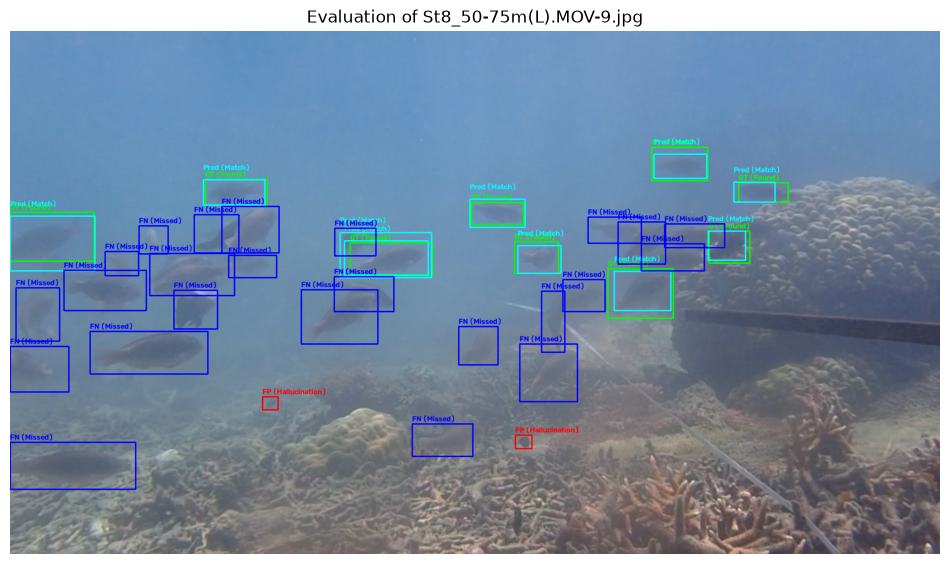

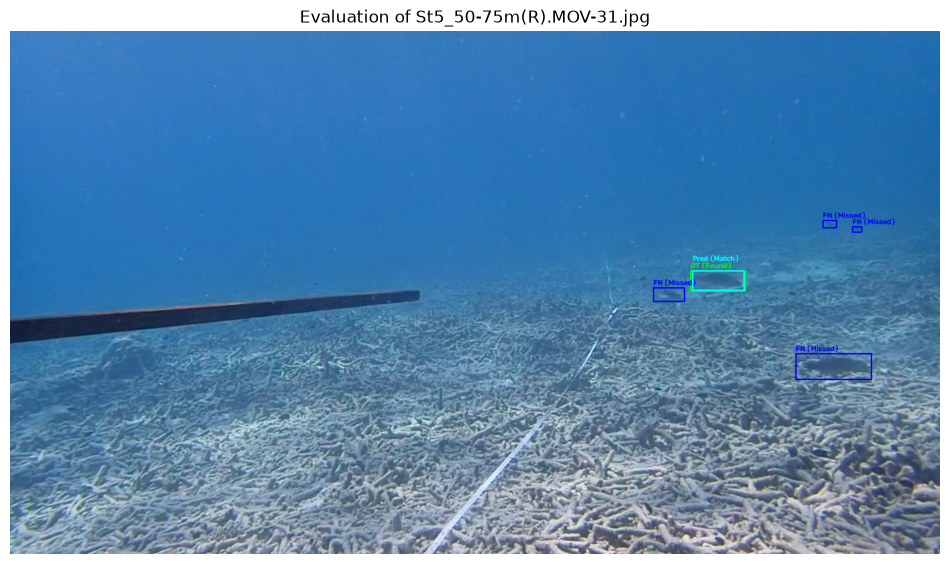

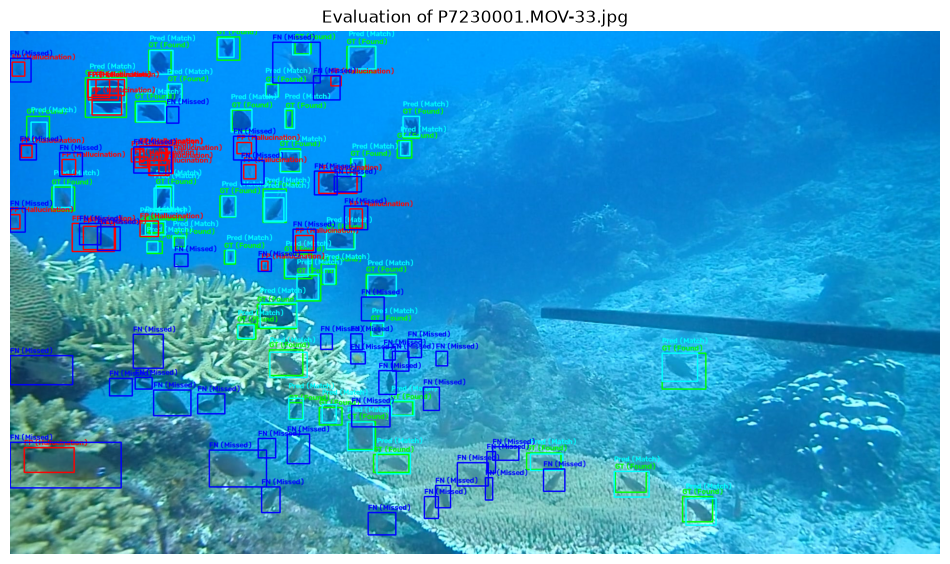

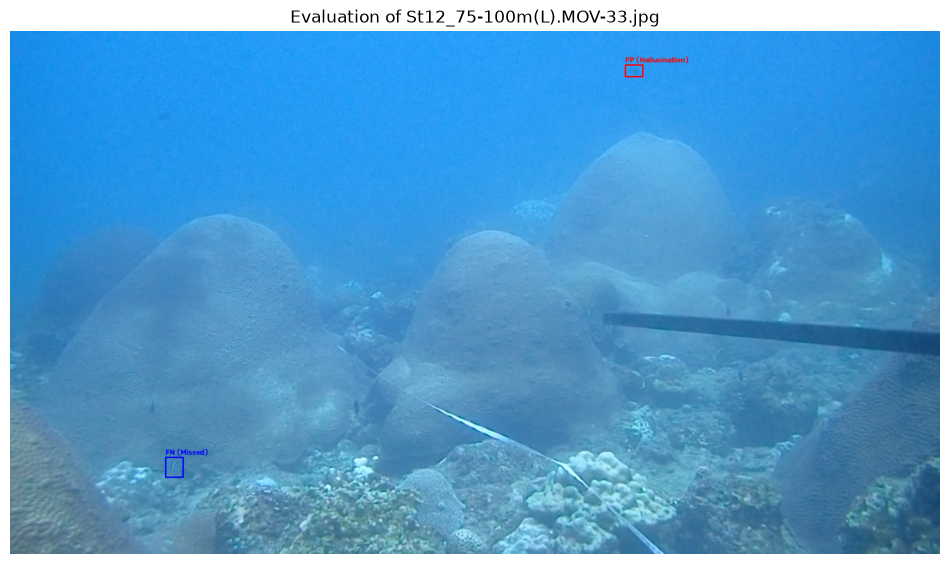

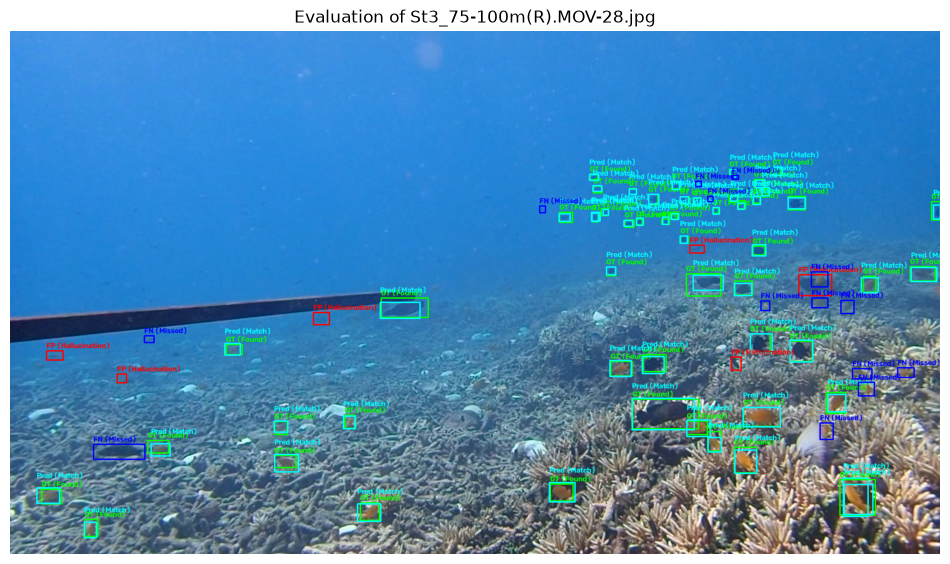

In [72]:
%matplotlib inline
visualize_misses_and_hallucinations(
    model_path=model_path, 
    images_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\UMT\images", 
    labels_dir=r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_detection\UMT\labels",
    num_visualize=5)

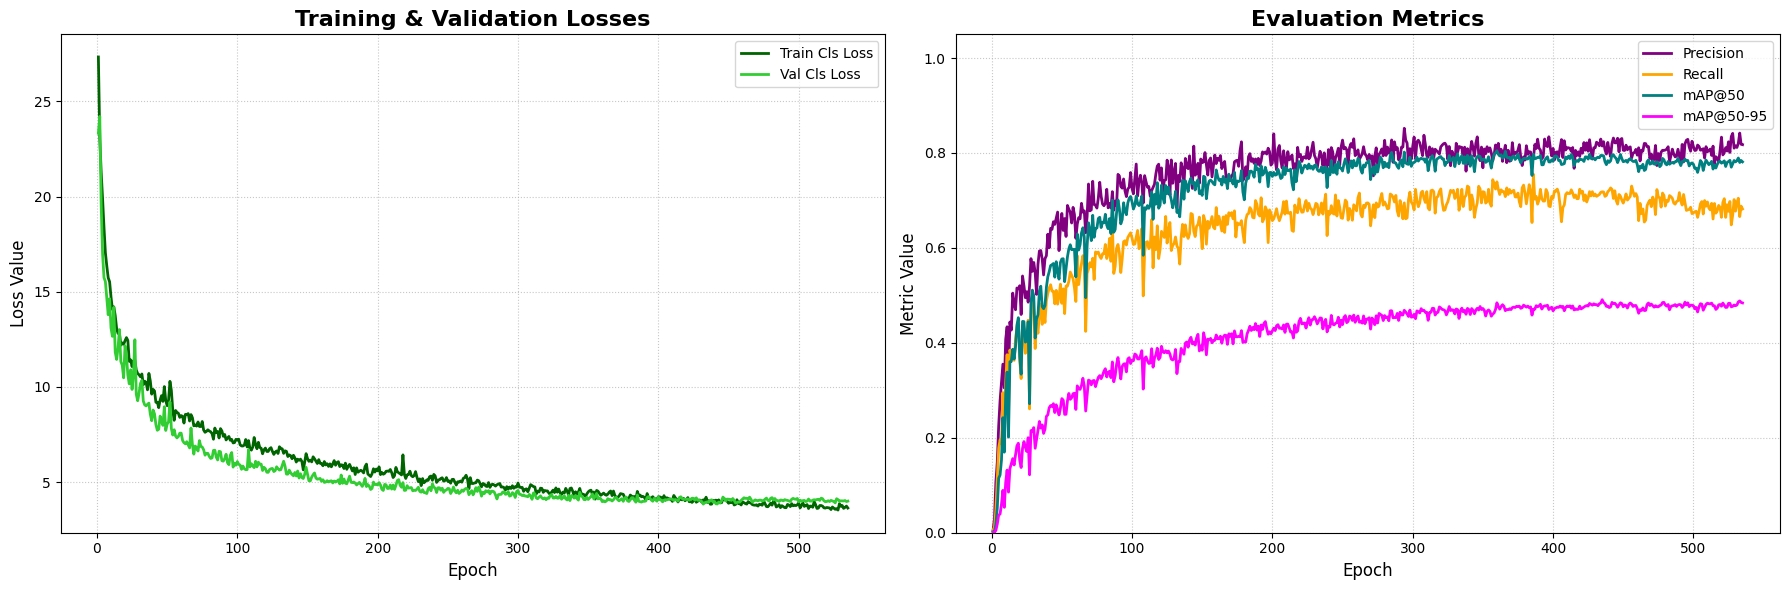

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_yolo_results(csv_path):
    # 1. Load the results file
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: Could not find the file at '{csv_path}'")
        return

    # 2. Strip leading/trailing whitespaces from column names
    # YOLO results.csv heavily uses spaces like '   metrics/precision(B)'
    df.columns = df.columns.str.strip()

    # Create a figure with two subplots (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # ==========================================
    # Graph 1: Training and Validation Losses
    # ==========================================
    ax_loss = axes[0]
    
    # Define the loss columns to plot
    loss_cols = {
        # 'train/box_loss': ('blue', '-', 'Train Box Loss'),
        'train/cls_loss': ('darkgreen', '-', 'Train Cls Loss'),
        # 'train/dfl_loss': ('red', '-', 'Train DFL Loss'),
        # 'val/box_loss': ('dodgerblue', '-', 'Val Box Loss'),
        'val/cls_loss': ('limegreen', '-', 'Val Cls Loss'),
        # 'val/dfl_loss': ('lightcoral', '-', 'Val DFL Loss')
    }

    # Plot each available loss column
    for col, (color, linestyle, label) in loss_cols.items():
        if col in df.columns:
            ax_loss.plot(df['epoch'], df[col], color=color, linestyle=linestyle, label=label, linewidth=2)
        else:
            print(f"Warning: Column '{col}' not found in CSV.")

    ax_loss.set_title('Training & Validation Losses', fontsize=16, fontweight='bold')
    ax_loss.set_xlabel('Epoch', fontsize=12)
    ax_loss.set_ylabel('Loss Value', fontsize=12)
    ax_loss.grid(True, linestyle=':', alpha=0.7)
    ax_loss.legend(fontsize=10)

    # ==========================================
    # Graph 2: Evaluation Metrics
    # ==========================================
    ax_metrics = axes[1]
    
    # Define the metric columns to plot
    metric_cols = {
        'metrics/precision(B)': ('purple', 'Precision'),
        'metrics/recall(B)': ('orange', 'Recall'),
        'metrics/mAP50(B)': ('teal', 'mAP@50'),
        'metrics/mAP50-95(B)': ('magenta', 'mAP@50-95')
    }

    # Plot each available metric column
    for col, (color, label) in metric_cols.items():
        if col in df.columns:
            ax_metrics.plot(df['epoch'], df[col], color=color, label=label, linewidth=2)
        else:
            print(f"Warning: Column '{col}' not found in CSV.")

    ax_metrics.set_title('Evaluation Metrics', fontsize=16, fontweight='bold')
    ax_metrics.set_xlabel('Epoch', fontsize=12)
    ax_metrics.set_ylabel('Metric Value', fontsize=12)
    ax_metrics.set_ylim(0, 1.05) # Metrics usually scale from 0 to 1
    ax_metrics.grid(True, linestyle=':', alpha=0.7)
    ax_metrics.legend(fontsize=10)

    # Display the plots
    plt.tight_layout()
    plt.show()

# --- Run the Script ---
# Ensure your CSV file is in the same directory or provide the absolute path
if __name__ == "__main__":
    csv_file_path = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\ultralytics\runs\detect\Detection_For_IS\detection_Only_training_run-with_medium_pretrained_weights\results.csv" 
    plot_yolo_results(csv_file_path)